### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

#### Load Data

In [8]:
df = pd.read_csv('data\data_points.csv')

X = df[['x1', 'x2']].values

print(X.shape)
type(X)


(300, 2)


numpy.ndarray

### Finding closest centroids

In [9]:
def find_closest_centroids(X, centroids):
    """
    Computes the centroid memberships for every example
    
    Args:
        X (ndarray): (m, n) Input values      
        centroids (ndarray): (K, n) centroids
    
    Returns:
        idx (array_like): (m,) closest centroids
    
    """

    # Set K
    K = centroids.shape[0]

    # You need to return the following variables correctly
    idx = np.zeros(X.shape[0], dtype=int)
    
    

    ### START CODE HERE ###
    
    m=X.shape[0]
    
    print('X.shape = {print(X.shape)}')
    
    for i in range(m):
        min_dis=np.inf
        i_idx=0
        for j in range(K):
            dis= np.linalg.norm(X[i] - centroids[j])
            
            if (min_dis>dis):
                min_dis=dis
                i_idx=j
                
        idx[i]=i_idx
            
        
     ### END CODE HERE ###
    
    return idx

In [10]:
# Select an initial set of centroids (3 Centroids)
initial_centroids = np.array([[3,3], [6,2], [8,5]])

# Find closest centroids using initial_centroids
idx = find_closest_centroids(X, initial_centroids)

# Print closest centroids for the first three elements
print("First three elements in idx are:", idx[:3])

X.shape = {print(X.shape)}
First three elements in idx are: [0 2 1]


### Computing centroid means

In [11]:
# UNQ_C2
# GRADED FUNCTION: compute_centroids

def compute_centroids(X, idx, K):
    """
    Returns the new centroids by computing the means of the 
    data points assigned to each centroid.
    
    Args:
        X (ndarray):   (m, n) Data points
        idx (ndarray): (m,) Array containing index of closest centroid for each 
                       example in X. Concretely, idx[i] contains the index of 
                       the centroid closest to example i
        K (int):       number of centroids
    
    Returns:
        centroids (ndarray): (K, n) New centroids computed
    """
    
    # Useful variables
    m, n = X.shape
    
   
    
    # You need to return the following variables correctly
    centroids = np.zeros((K, n))
    
    ### START CODE HERE ###
    '''for i in range(K):
        count=0
        summ=np.zeros((1,2))
        for j in range(n):
            summ+=X[i] if centroids[j]==X[i] else np.zeros((1,2))
            count+=1
        
        avg=summ/np.array([count,count])
        
        centroids[i]=avg
            
        '''
    
    for k in range(K):
        points = X[idx == k] 
        centroids[k] = np.mean(points, axis = 0)

    ### END CODE HERE ## 
    
    return centroids

In [12]:
K = 3
centroids = compute_centroids(X, idx, K)

print("The centroids are:", centroids)


The centroids are: [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


### K-means on a sample dataset (Run K-means)

In [17]:
def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):
    """
    Runs the K-Means algorithm on data matrix X, where each row of X
    is a single example
    """
    
    # Initialize values
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids    
    idx = np.zeros(m)
    plt.figure(figsize=(8, 6))

    # Run K-Means
    for i in range(max_iters):
        
        #Output progress
        print("K-Means iteration %d/%d" % (i, max_iters-1))
        
        # For each example in X, assign it to the closest centroid
        idx = find_closest_centroids(X, centroids)
        
        # Optionally plot progress
        if plot_progress:
            plt.clf()
            plt.scatter(X[:, 0], X[:, 1], c=idx, s=50, cmap='viridis', marker='o', edgecolor='k')
            plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='x', label='Centroids')
            plt.title(f'Iteration {i+1}')       
            previous_centroids = centroids
            
        # Given the memberships, compute new centroids
        centroids = compute_centroids(X, idx, K)
    plt.show() 
    return centroids, idx

## Random initialization

In [21]:
def kMeans_init_centroids(X, K):
    """
    This function initializes K centroids that are to be 
    used in K-Means on the dataset X
    
    Args:
        X (ndarray): Data points 
        K (int):     number of centroids/clusters
    
    Returns:
        centroids (ndarray): Initialized centroids
    """
    
    # Randomly reorder the indices of examples
    randidx = np.random.permutation(X.shape[0])
    
    # Take the first K examples as centroids
    centroids = X[randidx[:K]]
    
    return centroids

K-Means iteration 0/9
X.shape = {print(X.shape)}
K-Means iteration 1/9
X.shape = {print(X.shape)}
K-Means iteration 2/9
X.shape = {print(X.shape)}
K-Means iteration 3/9
X.shape = {print(X.shape)}
K-Means iteration 4/9
X.shape = {print(X.shape)}
K-Means iteration 5/9
X.shape = {print(X.shape)}
K-Means iteration 6/9
X.shape = {print(X.shape)}
K-Means iteration 7/9
X.shape = {print(X.shape)}
K-Means iteration 8/9
X.shape = {print(X.shape)}
K-Means iteration 9/9
X.shape = {print(X.shape)}


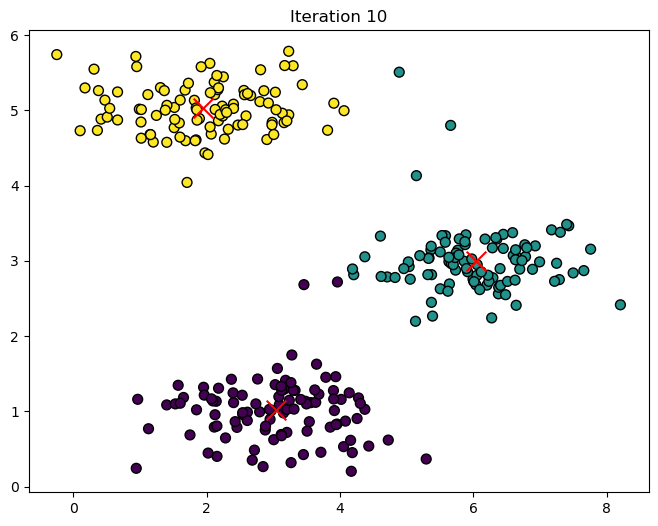

In [32]:
# Set number of centroids and max number of iterations
K = 3
max_iters = 10

# Set initial centroids by picking random examples from the dataset
initial_centroids = kMeans_init_centroids(X, K)

# Run K-Means
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)